In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
 
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate
 
warnings.filterwarnings("ignore")

In [2]:
PATH = ("/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/input/News_Category_Dataset_v3.json")

In [3]:
df = pd.read_json(PATH, lines = True)

In [4]:
print(df.shape)
df

(209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22
...,...,...,...,...,...,...
209522,https://www.huffingtonpost.com/entry/rim-ceo-t...,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sha...,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr...",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bow...,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked...",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smi...,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...,,2012-01-28


## Number of Distinct Categories

In [5]:
print(f"Number of distinct Categories is: {df.category.nunique()}")

Number of distinct Categories is: 42


## Distribution of Categories (RAW)

In [6]:
df.category.value_counts(sort = True, dropna = False)

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

## Distribution of Categories (Normalized)


In [7]:
df.category.value_counts(sort = True, dropna = False, normalize = True)

category
POLITICS          0.169916
WELLNESS          0.085645
ENTERTAINMENT     0.082863
TRAVEL            0.047249
STYLE & BEAUTY    0.046839
PARENTING         0.041956
HEALTHY LIVING    0.031948
QUEER VOICES      0.030292
FOOD & DRINK      0.030259
BUSINESS          0.028598
COMEDY            0.025772
SPORTS            0.024231
BLACK VOICES      0.021873
HOME & LIVING     0.020618
PARENTS           0.018876
THE WORLDPOST     0.017487
WEDDINGS          0.017435
WOMEN             0.017048
CRIME             0.017000
IMPACT            0.016628
DIVORCE           0.016351
WORLD NEWS        0.015745
MEDIA             0.014051
WEIRD NEWS        0.013254
GREEN             0.012514
WORLDPOST         0.012309
RELIGION          0.012299
STYLE             0.010758
SCIENCE           0.010528
TECH              0.010042
TASTE             0.010003
MONEY             0.008381
ARTS              0.007202
ENVIRONMENT       0.006892
FIFTY             0.006686
GOOD NEWS         0.006672
U.S. NEWS         0

## Count Nulls

In [8]:
print(f"Count of nulls per column: \n{df.isnull().sum()}")

Count of nulls per column: 
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64


## Remove duplicates

In [9]:
print(f"Original Shape: {df.shape}")
df.drop_duplicates(subset=['headline', 'short_description'], inplace=True)
print(f"Shape after dropping duplicated headlines and short description: {df.shape}")

Original Shape: (209527, 6)
Shape after dropping duplicated headlines and short description: (209038, 6)


## Get the Stats regarding Count of Words of HEADLINES

In [10]:
df['word_count_headlines'] = df['headline'].apply(lambda x: len(x.split()))
average_word_count_headlines = df['word_count_headlines'].mean()
print(f"Average word count in headlines: {average_word_count_headlines}")

Average word count in headlines: 9.602416785464843


In [11]:
max_word_count_headlines = df['word_count_headlines'].max()
print(f"Max word count in headlines: {max_word_count_headlines}")

Max word count in headlines: 44


In [12]:
min_word_count_headlines = df['word_count_headlines'].min()
print(f"Min word count in headlines: {min_word_count_headlines}")

Min word count in headlines: 0


In [13]:
df[df.word_count_headlines == 0]

,link,headline,category,short_description,authors,date,word_count_headlines
90944,https://www.huffingtonpost.com/entry/lincoln-2...,,POLITICS,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22,0
95567,https://www.huffingtonpost.com/entry/post_9671...,,RELIGION,Let everyone not wrapped in tired and disprove...,"Matthew Fox, ContributorRadical theologian Mat...",2015-06-30,0


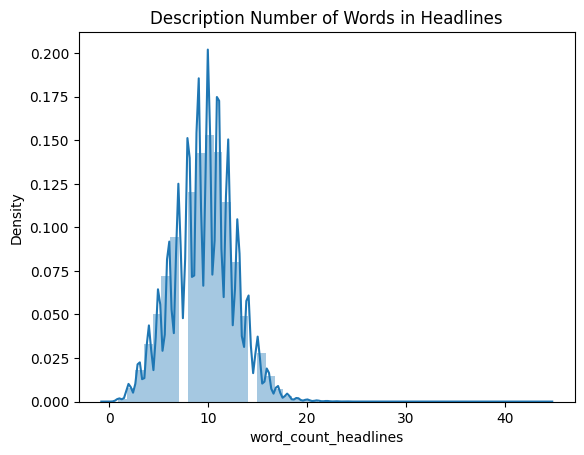

In [14]:
sns.distplot(df['word_count_headlines'])
plt.title('Description Number of Words in Headlines')
plt.show()

## Get the Average Count of words on Short Descriptions

In [15]:
df['word_count_short_desc'] = df['short_description'].apply(lambda x: len(x.split()))
average_word_count_short_desc = df['word_count_short_desc'].mean()
print(f"Average word count in Short Descriptions: {average_word_count_short_desc}")

Average word count in Short Descriptions: 19.674891646494896


In [16]:
max_word_count_short_desc = df['word_count_short_desc'].max()
print(f"Max word count in headlines: {max_word_count_short_desc}")

Max word count in headlines: 243


In [17]:
min_word_count_short_desc = df['word_count_short_desc'].min()
print(f"Min word count in headlines: {min_word_count_short_desc}")

Min word count in headlines: 0


In [18]:
print(df[df.word_count_short_desc == 0].shape)
df[df.word_count_short_desc == 0].head()

(19611, 8)


,link,headline,category,short_description,authors,date,word_count_headlines,word_count_short_desc
20773,https://www.huffingtonpost.com/entry/the-big-b...,The Big Blue Wave,COMEDY,,"Shan Wells, ContributorSciency sun venerator +...",2017-11-10,4,0
21523,https://www.huffingtonpost.com/entry/inside-ru...,"Inside Rukban Camp, One Of Syria’s Most Desper...",WORLD NEWS,,"Yasser Allawi, Syria Deeply",2017-10-31,9,0
22793,https://www.huffingtonpost.com/entry/syrian-re...,Syrian Refugees Return From Lebanon Only To Fl...,WORLD NEWS,,"Abby Sewell, Refugees Deeply",2017-10-14,11,0
32223,https://www.huffingtonpost.com/entry/your-guid...,Your Guide To The Best BBQ In St. Louis Accord...,TASTE,,,2017-06-19,12,0
34488,https://www.huffingtonpost.com/entry/the-bechd...,The Bechdel Test,COMEDY,,"Hilary Fitzgerald Campbell, ContributorHilary'...",2017-05-24,3,0


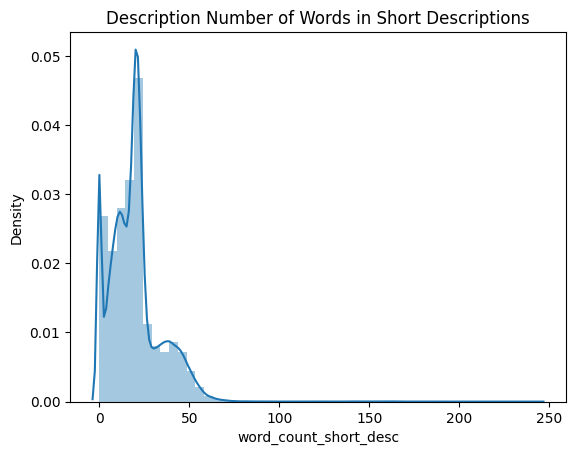

In [19]:
sns.distplot(df['word_count_short_desc'])
plt.title('Description Number of Words in Short Descriptions')
plt.show()

## Remove rows with 0 word count in headlines and short description

In [20]:
print(df.shape)
df.head()

(209038, 8)


,link,headline,category,short_description,authors,date,word_count_headlines,word_count_short_desc
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,11,29
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,13,28
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,13,12
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,9,25
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,11,25


In [21]:
df_no_nulls = df[~((df['word_count_headlines'] == 0) & (df['word_count_short_desc'] == 0))]
df_no_nulls.reset_index(inplace=True, drop=True)

In [22]:
print(df_no_nulls.shape)

(209037, 8)


## Combine categories

In [23]:
category_map = {
    "THE WORLDPOST": "WORLD NEWS",
    "WORLDPOST": "WORLD NEWS",
    "ARTS": "ARTS & CULTURE",
    "CULTURE & ARTS": "ARTS & CULTURE",
    "STYLE": "STYLE & BEAUTY",
    "TASTE": "FOOD & DRINK",
    "PARENTS": "PARENTING",
    "GREEN": "ENVIRONMENT",
    "MONEY": "BUSINESS",
    "HEALTHY LIVING": "WELLNESS",
    "SCIENCE" : "SCIENCE & TECH",
    "TECH" : "SCIENCE & TECH"
}

In [24]:
df_no_nulls['category'] = df_no_nulls['category'].replace(category_map)

In [25]:
print(len(df_no_nulls.category.unique()))
df_no_nulls.category.value_counts(sort = True, dropna = False)

31


category
POLITICS          35584
WELLNESS          24628
ENTERTAINMENT     17358
PARENTING         12660
STYLE & BEAUTY    11926
TRAVEL             9896
WORLD NEWS         9539
FOOD & DRINK       8434
BUSINESS           7743
QUEER VOICES       6343
COMEDY             5389
SPORTS             5077
BLACK VOICES       4578
HOME & LIVING      4288
SCIENCE & TECH     4261
ENVIRONMENT        4060
ARTS & CULTURE     3920
WEDDINGS           3653
CRIME              3558
WOMEN              3486
IMPACT             3482
DIVORCE            3423
MEDIA              2941
WEIRD NEWS         2777
RELIGION           2569
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
COLLEGE            1144
LATINO VOICES      1130
EDUCATION          1014
Name: count, dtype: int64

In [26]:
print(len(df_no_nulls.category.unique()))
df_no_nulls.category.value_counts(sort = True, dropna = False, normalize = True)

31


category
POLITICS          0.170228
WELLNESS          0.117816
ENTERTAINMENT     0.083038
PARENTING         0.060563
STYLE & BEAUTY    0.057052
TRAVEL            0.047341
WORLD NEWS        0.045633
FOOD & DRINK      0.040347
BUSINESS          0.037041
QUEER VOICES      0.030344
COMEDY            0.025780
SPORTS            0.024288
BLACK VOICES      0.021900
HOME & LIVING     0.020513
SCIENCE & TECH    0.020384
ENVIRONMENT       0.019422
ARTS & CULTURE    0.018753
WEDDINGS          0.017475
CRIME             0.017021
WOMEN             0.016676
IMPACT            0.016657
DIVORCE           0.016375
MEDIA             0.014069
WEIRD NEWS        0.013285
RELIGION          0.012290
FIFTY             0.006702
GOOD NEWS         0.006688
U.S. NEWS         0.006587
COLLEGE           0.005473
LATINO VOICES     0.005406
EDUCATION         0.004851
Name: proportion, dtype: float64

## Drop rows where the target (Category) is NULL

In [27]:
before = len(df_no_nulls)
df_no_nulls = df_no_nulls[df_no_nulls['category'].notna() & (df_no_nulls['category'].str.strip() != '')]
print(f"After dropping null category: {len(df_no_nulls):>7,}  (removed {before - len(df_no_nulls):,})")

After dropping null category: 209,037  (removed 0)


In [28]:
#Normalize the categories
df_no_nulls['category'] = df_no_nulls['category'].str.strip().str.upper()

## Remove categories with very low frequency 

In [29]:
MIN_CATEGORY_FREQ  = 0.01

In [30]:
freq = df_no_nulls['category'].value_counts(normalize=True)
keep_cats = freq[freq >= MIN_CATEGORY_FREQ].index.tolist()
drop_cats = freq[freq <  MIN_CATEGORY_FREQ].index.tolist()
 
print(f"Threshold: {MIN_CATEGORY_FREQ*100:.2f}% of corpus")
print(f"Categories KEPT: {len(keep_cats)}")
print(f"Categories DROPPED: {len(drop_cats)} --> {drop_cats}")
 
before = len(df_no_nulls)
df_no_nulls = df_no_nulls[df_no_nulls['category'].isin(keep_cats)].copy()
print(f"Rows after filter  : {len(df_no_nulls):,}  (removed {before - len(df_no_nulls):,} rows)")
print(f"\nFinal label count  : {df_no_nulls['category'].nunique()}")
print(df_no_nulls['category'].value_counts().to_string())

Threshold: 1.00% of corpus
Categories KEPT: 25
Categories DROPPED: 6 --> ['FIFTY', 'GOOD NEWS', 'U.S. NEWS', 'COLLEGE', 'LATINO VOICES', 'EDUCATION']
Rows after filter  : 201,573  (removed 7,464 rows)

Final label count  : 25
category
POLITICS          35584
WELLNESS          24628
ENTERTAINMENT     17358
PARENTING         12660
STYLE & BEAUTY    11926
TRAVEL             9896
WORLD NEWS         9539
FOOD & DRINK       8434
BUSINESS           7743
QUEER VOICES       6343
COMEDY             5389
SPORTS             5077
BLACK VOICES       4578
HOME & LIVING      4288
SCIENCE & TECH     4261
ENVIRONMENT        4060
ARTS & CULTURE     3920
WEDDINGS           3653
CRIME              3558
WOMEN              3486
IMPACT             3482
DIVORCE            3423
MEDIA              2941
WEIRD NEWS         2777
RELIGION           2569


## Add Headline and Short Description for more context. Will compare 2 variants later: With headline only vs with headline and short description

In [31]:
df_no_nulls['text_combined'] = df_no_nulls['headline'] + " [SEP] " + df_no_nulls['short_description']

In [32]:
print(df_no_nulls.shape)
df_no_nulls.head()

(201573, 9)


,link,headline,category,short_description,authors,date,word_count_headlines,word_count_short_desc,text_combined
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,13,12,23 Of The Funniest Tweets About Cats And Dogs ...
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,9,25,The Funniest Tweets From Parents This Week (Se...
7,https://www.huffpost.com/entry/puerto-rico-wat...,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS,More than half a million people remained witho...,"DÁNICA COTO, AP",2022-09-22,9,19,Puerto Ricans Desperate For Water After Hurric...
8,https://www.huffpost.com/entry/mija-documentar...,How A New Documentary Captures The Complexity ...,ARTS & CULTURE,"In ""Mija,"" director Isabel Castro combined mus...",Marina Fang,2022-09-22,13,22,How A New Documentary Captures The Complexity ...
9,https://www.huffpost.com/entry/biden-un-russia...,Biden At UN To Call Russian War An Affront To ...,WORLD NEWS,White House officials say the crux of the pres...,"Aamer Madhani, AP",2022-09-21,12,26,Biden At UN To Call Russian War An Affront To ...


## Final Dataframe

In [33]:
df_no_nulls.reset_index(inplace = True, drop = True)

In [34]:
df_no_nulls['row_id'] = df_no_nulls.index.to_series().apply(lambda x: f"{x + 1:06d}")

In [35]:
df_final = df_no_nulls[['row_id','headline', 'category', 'text_combined']].copy()

In [36]:
print(df_final.shape)
df_final.head()

(201573, 4)


,row_id,headline,category,text_combined
0,000001,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...
1,000002,The Funniest Tweets From Parents This Week (Se...,PARENTING,The Funniest Tweets From Parents This Week (Se...
2,000003,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS,Puerto Ricans Desperate For Water After Hurric...
3,000004,How A New Documentary Captures The Complexity ...,ARTS & CULTURE,How A New Documentary Captures The Complexity ...
4,000005,Biden At UN To Call Russian War An Affront To ...,WORLD NEWS,Biden At UN To Call Russian War An Affront To ...


In [37]:
output_path = "/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/output/01_output_clean_data.jsonl"
df_final.to_json(output_path, orient='records', lines=True)